# Michael Vazquez<br>Econ 586, Assignment2<br>Link to code:

# Imports.

In [18]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import sympy as sp
from sympy import symbols, diff, limit, oo, Rational, simplify, latex, Eq, Function

from IPython.display import display, Math, Image

import os

sp.init_printing(use_latex='mathjax')


# Question 1: Aggregate Production Function
Note: All formulas for this question are found in "solow-am2026.pdf".

The given aggregate production function is the Cobb-Douglas production function, per page 8 of "solow-am2026.pdf". We have:

$$Y = F(K, L) = K^\alpha L^{1-\alpha}, \quad 0 < \alpha < 1$$

Let $y = Y/L$ and $k = K/L$.

In [2]:
# Assign Sympy variables for Cobb-Douglas production function.
k, alpha = symbols('k alpha', positive=True)
f = k**alpha

## Question 1.1: Intensive form $f(k)$

Reference: pages 7, 17, and 23 of "solow-am2026.pdf".

The production function has neoclassical properties, one of which is constant returns to scale: $F(\lambda K, \lambda L) = \lambda F(K, L)$ for all $\lambda > 0$ .

Setting $\lambda = 1/L$, it follows that output per capicat can be expressed as $y = f(k)$:

$$y = \frac{Y}{L} = \frac{F(K,L)}{L} = F\!\left(\frac{K}{L},\, 1\right) = \left(\frac{K}{L}\right)^\alpha \cdot 1^{1-\alpha} = k^\alpha$$

$$\boxed{y = f(k) = k^\alpha}$$

## Question 1.2: Properties of $f(k) = k^\alpha$

We want to show that f is **strictly increasing**, **continuously differentiable**, and **strictly concave** on $(0, \infty)$. Per page 7 of "solow-am2026.pdf": "F is continuously differentiable, strictly increasing, strictly concave." Thus, taking the first and second derivative of the intensive form $f(k) = k^\alpha$ is enough to show the required properties.

In [3]:
# First derivative.
f_prime = diff(f, k)
display(Math(r"f'(k) = " + latex(f_prime)))

<IPython.core.display.Math object>

In [4]:
# Second derivative.
f_double = diff(f_prime, k)
display(Math(r"f''(k) = " + latex(simplify(f_double))))

<IPython.core.display.Math object>

**Strictly Increasing:** $f'(k) = \alpha k^{\alpha-1}$. Since $\alpha \in (0,1)$ and $k > 0$, both $\alpha > 0$ and $k^{\alpha-1} > 0$, so $f'(k) > 0$.

**Continuously Differentiable:** $f(k) = k^\alpha$ is a power function with $0 < \alpha < 1$. Power functions are infinitely differentiable on $(0, \infty)$, so $f$ is $C^1$.

**Strictly Concave:** $f''(k) = \alpha(\alpha-1)k^{\alpha-2}$. Since $\alpha - 1 < 0$ and $k^{\alpha-2} > 0$, we have $f''(k) < 0$ for all $k > 0$.

## Question 1.3: Inada Conditions

We want to show that the production function $f'(k) = \alpha k^{\alpha-1}$ satisfies the Inada conditions given in the question:

1. $f'(k) \to 0 \text{ as } k \to \infty$
2. $f'(k) \to \infty \text{ as } k \to 0$

Recall that $\alpha \in (0,1)$ and thus the exponent $(\alpha - 1) < 0$, call it $-c$. Then:
$$f'(k) = \alpha k^{-c} = \frac{\alpha}{k^c}$$
Letting $k \to \infty$ clearly gives $\lim_{k \to \infty} f'(k) = 0$, which proves the first condition.

For the second condition, assume $k \gt 0$ because zero or negative capital makes no sense in the model. Consider the limit from the right as $k \to 0$, and observe that the limit goes off to positive infinity, as we know from calculus.

Thus, both Inada conditions are mathematically satisfied. To check numerically, we can use SymPy and plug in $\alpha = 1/3$.

In [5]:
# Plug alpha = 1/3 into the first derivative of f.
f_prime_eval = f_prime.subs(alpha, Rational(1, 3))

lim_inf  = limit(f_prime_eval, k, oo)
lim_zero = limit(f_prime_eval, k, 0, '+')

display(Math(r"\lim_{k \to \infty} f'(k) = " + latex(lim_inf)))
display(Math(r"\lim_{k \to 0^+} f'(k) = " + latex(lim_zero)))

print("Both Inada conditions satisfied.")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Both Inada conditions satisfied.


# Question 2: Steady State

## Question 2.1: Finding steady state $k^*$.

Per page 19 of "solow-am2026.pdf", the fundamental growth equation of the Solow model is:

$$\dot{k} = sf(k) - (n + \delta)k$$

Per page 22 of the same PDF, the fundamental growth equation is said to be in a *steady state* at $k^*$ when $\dot{k} = 0$:

$$sf(k^*) = (n + \delta)k^*$$

Let $f(k) = k^\alpha$, and substitute this into the steady state equation:

$$s(k^{*\alpha}) = (n+\delta)k^*$$

Dividing both sides by $k^*$:

$$s(k^{*\alpha - 1}) = (n + \delta)$$

Dividing both sides by $s$:

$$k^{*\alpha-1} = \frac{n+\delta}{s}$$

Raising both sides to the power $\frac{-1}{\alpha-1} = \frac{1}{1-\alpha}$ gives the steady state:

$$\boxed{k^* = \left(\frac{s}{n+\delta}\right)^{\!1/(1-\alpha)}}$$

This is exactly the steady state shown in the example on slide 22 using a Cobb Douglas function.


## Question 2.2: Increases in model parameters - $s$, $n$, $\delta$, $\alpha$ - and the impact to $k^*$.

In [6]:
# Use SymPy to define the steady state k* found in Question 2.1.
s, n, delta, alpha = symbols('s n delta alpha', positive=True)
k_star = ((n + delta) / s) ** (1 / (alpha - 1))

dk_ds = simplify(diff(k_star, s))
dk_dn = simplify(diff(k_star, n))
dk_ddelta = simplify(diff(k_star, delta))
dk_dalpha = simplify(diff(k_star, alpha))

display(Math(r"\text{From Question 2.1, we have the steady state:}\\k^* = \left(\frac{s}{n+\delta}\right)^{\!1/(1-\alpha)}"))
display(Math(r"\text{Exact rates of change in }k^* \text{ with respect to each model parameter:}"))
display(Math(r"\frac{\partial k^*}{\partial s} = " + latex(dk_ds)))
display(Math(r"\frac{\partial k^*}{\partial n} = " + latex(dk_dn)))
display(Math(r"\frac{\partial k^*}{\partial \delta} = " + latex(dk_ddelta)))
display(Math(r"\frac{\partial k^*}{\partial \alpha} = " + latex(dk_dalpha)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<!-- | Model Parameter | Effect on $k^*$ | Interpretation |
|-----------|----------------|-----------|
| $s \uparrow$ | $k^* \uparrow$ | $s/(n+\delta)$ increases |
| $n \uparrow$ | $k^* \downarrow$ | $n+\delta$ increases, so $s/(n+\delta)$ decreases |
| $\delta \uparrow$ | $k^* \downarrow$ | $n+\delta$ increases, so $s/(n+\delta)$ decreases |
| $\alpha \uparrow$ | $k^* \uparrow$ (if $s/(n+\delta)>1$) | Exponent $1/(1-\alpha)$ increases| -->

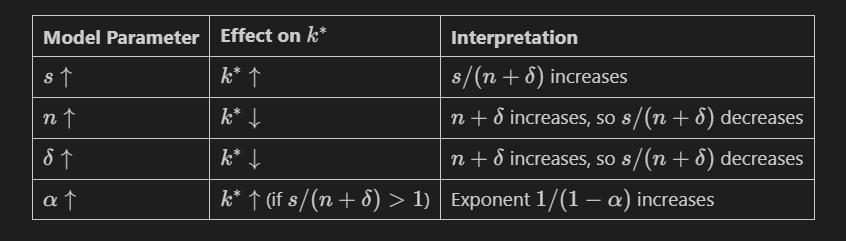

In [20]:
# The latex isn't rendering properly when exporting to HTML. Use a screenshot instead.
assignment_1_dir = os.getenv("ECON_586_ASSIGNMENT_1_DIR")
assignment_1_images_dir = os.getenv("ECON_586_ASSIGNMENT_1_IMAGES_DIR")
display(Image(rf'{assignment_1_images_dir}\\table_q2.png'))

# Question 3.0: Numerical Solow Model and steady state.

Using steady state found in Question 2.1:

$k^* = (s/(n+\delta))^{1/(1-\alpha)}$

Assign values to model parameters: $s = 0.1,\ \delta = 0.025,\ n = 0,\ \alpha = 0.3$

## Question 3.1: Steady state and Solow diagram.

In [7]:
# Assign the initial values of the parameters. Question 3.2 concerns changes from these values.
s_0 = 0.10
delta_0 = 0.025
n_0 = 0.0
alpha_0 = 0.3

# f(k) function, with the alpha added for code reusability.
def f_num(k, a=alpha_0):
    return k**a

# k* = ...the steady state formula.
def k_star_num(s, n, d, a=alpha_0):
    """Steady state k* = (s/(n+delta))^(1/(1-alpha))"""
    return (s / (n + d)) ** (1 / (1 - a))

# k* with the initial values.
ks_base = k_star_num(s_0, n_0, delta_0)
# y* with the initial values.
ys_base = f_num(ks_base)

print(f"Steady state k* = {ks_base:.4f}")
print(f"Steady state y* = f(k*) = {ys_base:.4f}")

Steady state k* = 7.2458
Steady state y* = f(k*) = 1.8114


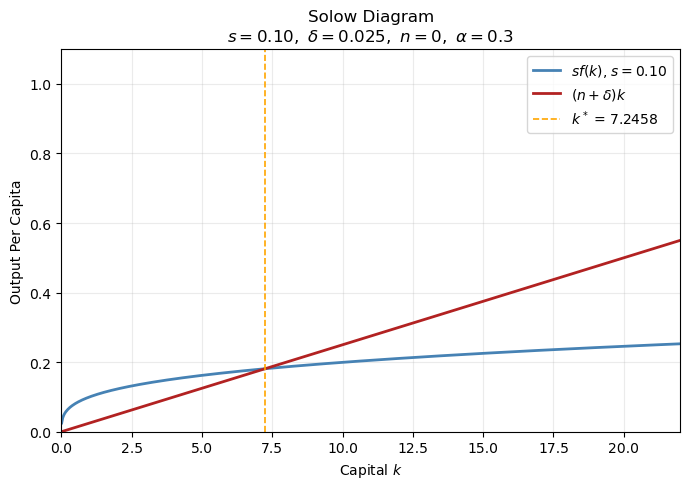

In [8]:
# Draw the Solow diagram.
k_grid = np.linspace(0.01, 22, 600)
sf_base = s_0 * k_grid**alpha_0
breakeven = (n_0 + delta_0) * k_grid

fig, ax = plt.subplots(figsize=(7, 5))

# Plot the 3 lines/curves.
ax.plot(k_grid, sf_base, color='steelblue', linewidth=2, label=r'$sf(k)$, $s=0.10$')
ax.plot(k_grid, breakeven, color='firebrick',  linewidth=2, label=r'$(n+\delta)k$')
ax.axvline(ks_base, color='orange', ls='--', linewidth=1.2, label=r'$k^*$ = 7.2458')

ax.set_xlim(0, 22); ax.set_ylim(0, 1.1)
ax.set_xlabel('Capital $k$')
ax.set_ylabel('Output Per Capita')
ax.set_title(r'Solow Diagram' + '\n' + r'$s=0.10,\ \delta=0.025,\ n=0,\ \alpha=0.3$')
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Question 3.2: Parameter changes.

We consider two permanent shocks starting from the baseline steady state:
1. Savings rate $s$ increases from $0.10$ to $0.12$
2. Depreciation rate $\delta$ decreases from $0.025$ to $0.020$


In [9]:
s_new = 0.12
delta_new = 0.02

ks_s = k_star_num(s_new, n_0, delta_0)
ks_d = k_star_num(s_0, n_0, delta_new)

display(Math(r"\text{Change in } s \text{ and the resulting change in } k^* \text{:}"))
print(f"{s_0} --> {s_new}  =>  k*: {ks_base:.4f} --> {ks_s:.4f}  (+{ks_s-ks_base:.4f}, +{100*(ks_s/ks_base-1):.1f}%)")

display(Math(r"\text{Change in } \delta \text{ and the resulting change in } k^* \text{:}"))
print(f"{delta_0} --> {delta_new}  =>  k*: {ks_base:.4f} --> {ks_d:.4f}  (+{ks_d-ks_base:.4f}, +{100*(ks_d/ks_base-1):.1f}%)")

<IPython.core.display.Math object>

0.1 --> 0.12  =>  k*: 7.2458 --> 9.4016  (+2.1558, +29.8%)


<IPython.core.display.Math object>

0.025 --> 0.02  =>  k*: 7.2458 --> 9.9662  (+2.7204, +37.5%)


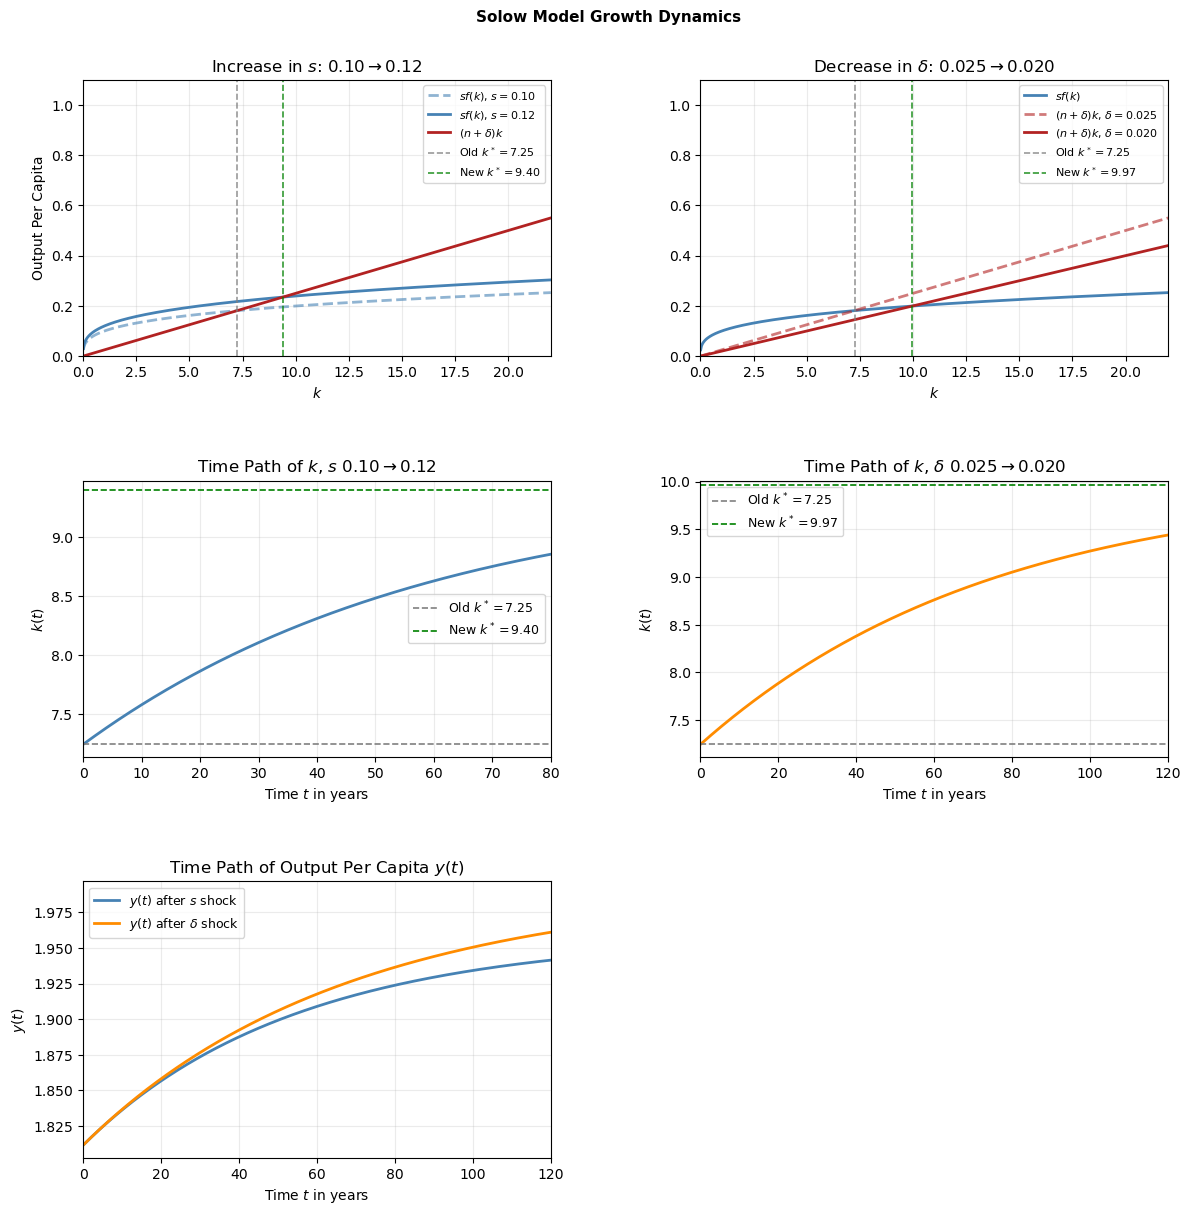

In [10]:
def simulate_solow(k0, s, n, d, T=1000, dt=0.25):
    """Simulate some numbers for Solow diagram."""
    k = np.zeros(T)
    k[0] = k0
    for t in range(1, T):
        # Following the fundamental growth equation formula, except over time.
        k[t] = k[t-1] + dt * (s * f_num(k[t-1]) - (n + d) * k[t-1])
    return k

T = 1000
# Multiplying by 0.25 plots in years instead of quarters.
time = np.arange(T) * 0.25

k_path_s = simulate_solow(ks_base, s_new, n_0, delta_0)
k_path_d = simulate_solow(ks_base, s_0, n_0, delta_new)

sf_new = s_new * k_grid**alpha_0
breakeven_new = (n_0 + delta_new) * k_grid

fig = plt.figure(figsize=(14, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.32)

# Grid (1, 1) - s shock Solow diagram.
ax = fig.add_subplot(gs[0, 0])
ax.plot(k_grid, sf_base,  color='steelblue', lw=2, ls='--', alpha=0.6, label=r'$sf(k)$, $s=0.10$')
ax.plot(k_grid, sf_new,   color='steelblue', lw=2, label=r'$sf(k)$, $s=0.12$')
ax.plot(k_grid, breakeven,  color='firebrick',  lw=2, label=r'$(n+\delta)k$')
ax.axvline(ks_base, color='gray',  ls='--', lw=1.2, alpha=0.8, label=f'Old $k^*={ks_base:.2f}$')
ax.axvline(ks_s,    color='green', ls='--', lw=1.2, alpha=0.8, label=f'New $k^*={ks_s:.2f}$')
ax.set_xlim(0,22); ax.set_ylim(0,1.1)
ax.set_xlabel('$k$')
ax.set_ylabel('Output Per Capita')
ax.set_title(r'Increase in $s$: $0.10 \to 0.12$')
ax.legend(fontsize=8); ax.grid(alpha=0.25)

##########################################################
# Time paths. Could not find a specific example of a time path in
# the chapter 2 materials, but page 39 of "solow-am2026.pdf" gives an example:
# "Example: Starting from steady state, analyze the consequences of a
# permanent fall in the depreciation rate δ"
# Per the example, I'll plot the old and new steady states along with the plot
# of growth over time.
# Grid (1, 2) – delta shock Solow diagram
ax = fig.add_subplot(gs[0, 1])
ax.plot(k_grid, sf_base, color='steelblue', lw=2, label=r'$sf(k)$')
ax.plot(k_grid, breakeven, color='firebrick', lw=2, ls='--', alpha=0.6, label=r'$(n+\delta)k$, $\delta=0.025$')
ax.plot(k_grid, breakeven_new,  color='firebrick',  lw=2, label=r'$(n+\delta)k$, $\delta=0.020$')
ax.axvline(ks_base, color='gray',  ls='--', lw=1.2, alpha=0.8, label=f'Old $k^*={ks_base:.2f}$')
ax.axvline(ks_d,    color='green', ls='--', lw=1.2, alpha=0.8, label=f'New $k^*={ks_d:.2f}$')
ax.set_xlim(0,22); ax.set_ylim(0,1.1)
ax.set_xlabel('$k$')
ax.set_title(r'Decrease in $\delta$: $0.025 \to 0.020$')
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# Grid (2, 1) – k time path after s shock.
ax = fig.add_subplot(gs[1, 0])
ax.plot(time, k_path_s, color='steelblue', lw=2)
ax.axhline(ks_base, color='gray',  ls='--', lw=1.2, label=f'Old $k^*={ks_base:.2f}$')
ax.axhline(ks_s, color='green', ls='--', lw=1.2, label=f'New $k^*={ks_s:.2f}$')
ax.set_xlim(0,80)
ax.set_xlabel('Time $t$ in years'); ax.set_ylabel('$k(t)$')
ax.set_title(r'Time Path of $k$, $s$ $0.10 \to 0.12$')
ax.legend(fontsize=9); ax.grid(alpha=0.25)
##########################################################

# Grid (2, 2) – k time path after delta shock.
ax = fig.add_subplot(gs[1, 1])
ax.plot(time, k_path_d, color='darkorange', lw=2)
ax.axhline(ks_base, color='gray',  ls='--', lw=1.2, label=f'Old $k^*={ks_base:.2f}$')
ax.axhline(ks_d, color='green', ls='--', lw=1.2, label=f'New $k^*={ks_d:.2f}$')
ax.set_xlim(0,120)
ax.set_xlabel('Time $t$ in years'); ax.set_ylabel('$k(t)$')
ax.set_title(r'Time Path of $k$, $\delta$ $0.025 \to 0.020$')
ax.legend(fontsize=9); ax.grid(alpha=0.25)

# Grid (3, 2) – output per capita time paths
ax = fig.add_subplot(gs[2, 0])
ax.plot(time, k_path_s**alpha_0, color='steelblue',  lw=2, label='$y(t)$ after $s$ shock')
ax.plot(time, k_path_d**alpha_0, color='darkorange', lw=2, label=r'$y(t)$ after $\delta$ shock')
ax.set_xlim(0,120)
ax.set_xlabel('Time $t$ in years'); ax.set_ylabel('$y(t)$')
ax.set_title('Time Path of Output Per Capita $y(t)$')
ax.legend(fontsize=9); ax.grid(alpha=0.25)

fig.suptitle(
    'Solow Model Growth Dynamics',
    fontsize=11,
    fontweight='bold',
    y=0.93
)

plt.show()

**Interpretation**, referencing pages 32 and 39 of "solow-am2026.pdf".

In the simulated data, the economy starts at the old $k^*$ and converges smoothly and monotonically to the new steady state $k^*$, demonstrating the globally stable dynamics of the Solow model. Both the shock to $s$ and $\delta$ are pure level effects. That is, the long-run growth rate of output per capita is zero in both steady states, only the level of $y$ changes.


# Question 4: Interpreting per capita consumption graphs.
We are told the graphs use U.S. per capita consumption, quarterly and in logs, from 1948:I to 2010:I.

## Question 4.1: Raw data and HP filter.

Notice that the steps described in this question are somewhat similar to what we did for assignment 1.

To obtain the raw data, we would download quarterly real personal consumption expenditure per capita from FRED, then take the natural log of consumption.

The cyclical component would be extracted using the HP filter with the quarterly smoothing parameter $\lambda = 1600$. The trend is shown in Figure 1, and the cyclical component found by subtracting the trend from the logged consumption is shown in Figure 2.


## Question 4.2: AR(1) Parameter Estimation

**References: "solowstochastic2026.pdf" pages 8 and 18.**

The suggeested AR(1) process has the form:

$$c_t = \rho\, c_{t-1} + \varepsilon_t$$

Per page 8, we assume the stability condition $|\rho| < 1$ and the specification of $\varepsilon_t$ as white noise with variance $\sigma_\varepsilon^2$. We will estimate the parameters of this model, namely $\rho$ and the standard deviation of the white noise, $\sigma_\varepsilon$.

**Step 1 — Estimating $\rho$:**

Multiply both sides by $c_{t-1}$ and take expectations:

$$E[c_t c_{t-1}] = \rho\, E[c_{t-1}^2] + E[\varepsilon_t c_{t-1}]$$

Since $\varepsilon_t$ is white noise, $E[\varepsilon_t c_{t-1}] = 0$, giving:

$$E[c_t c_{t-1}] = \rho\, E[c_{t-1}^2] \implies \rho = \frac{E[c_t c_{t-1}]}{E[c_{t-1}^2]} = \text{lag-1 autocorrelation}$$

**Step 2 — Estimating $\sigma_\varepsilon$:**

Square the model equation and take expectations, where cross term expectations are zero as seen in Step 1:

$$E[c_t^2] = \rho^2 E[c_{t-1}^2] + E[\varepsilon_t^2]$$

Per page 18, we may also assume stationarity, which gives $E[c_t^2] = E[c_{t-1}^2] = \sigma_c^2$. Then we have the estimate:

$$\sigma_c^2 = \rho^2 \sigma_c^2 + \sigma_\varepsilon^2 \implies \sigma_\varepsilon = \sigma_c\sqrt{1 - \rho^2}$$

Thus we have our parameter estimates, which we may denote with a hat:

$$\boxed{\hat{\rho} = \frac{E[c_t c_{t-1}]}{E[c_{t-1}^2]}}$$

$$\boxed{\hat{\sigma}_\varepsilon = \sigma_c\sqrt{1 - \hat{\rho}^2}}$$

## Question 4.3: Is the AR(1) model plausible?

**Answer: No.**

For an AR(1) with $\rho > 0$, the lag-$j$ autocorrelation equals $\rho^j > 0$ for all $j$. However, Figure 3 shows several lags with negative autocorrelations, which is mathematically impossible. The AR(1) specification is therefore not plausible at all.

These findings are consistent with what we found in assignment 1 Question 4.2, where the consumption column C had a standard deviation of $\sigma_C = 0.0080$ and a lag-1 autocorrelation of $\rho_1 = 0.8238$, nearly identical to the values of $0.0083$ and $0.8386$, respectively, given here in Question 4.